In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score, precision_score,
    recall_score, roc_auc_score
)
from sklearn.feature_selection import mutual_info_classif

from xgboost import XGBClassifier
from hmmlearn.hmm import GaussianHMM

from sklearn.utils import check_random_state

SEED = 42
np.random.seed(SEED)

plt.style.use("default")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

### Helpers


In [2]:
def standardize_yf_frame(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy()

    if isinstance(df.columns, pd.MultiIndex):
        # Prefer the level that actually contains OHLC names
        for lvl in range(df.columns.nlevels):
            vals = set(map(str, df.columns.get_level_values(lvl)))
            if {"Open", "High", "Low", "Close"}.issubset(vals) or "Close" in vals:
                df.columns = df.columns.get_level_values(lvl)
                break
        else:
            df.columns = ["_".join(map(str, col)).strip("_") for col in df.columns]

    df.columns = [str(c).strip() for c in df.columns]

    if "Adj Close" in df.columns and "Close" not in df.columns:
        df = df.rename(columns={"Adj Close": "Close"})

    # Recover standard names if yfinance embedded ticker names into the column label
    for base in ["Open", "High", "Low", "Close", "Volume"]:
        if base not in df.columns:
            candidates = [
                c for c in df.columns
                if str(c) == base or str(c).endswith(f"_{base}") or str(c).startswith(f"{base}_")
            ]
            if candidates:
                df = df.rename(columns={candidates[0]: base})

    return df


def download_ticker(ticker: str, start: str, end: str) -> pd.DataFrame:
    raw = yf.download(
        ticker,
        start=start,
        end=end,
        progress=False,
        auto_adjust=False,
        actions=False,
        group_by="column",
    )
    df = standardize_yf_frame(raw).sort_index()
    if df.empty:
        raise ValueError(f"No data returned for {ticker}")
    return df


def compute_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)

    avg_gain = gain.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def compute_macd(close: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal
    return macd, macd_signal, macd_hist


def compute_bollinger_width(close: pd.Series, window: int = 20, num_std: float = 2.0) -> pd.Series:
    mid = close.rolling(window).mean()
    std = close.rolling(window).std()
    upper = mid + num_std * std
    lower = mid - num_std * std
    width = (upper - lower) / mid
    return width


def compute_adx(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 14):
    high = high.astype(float)
    low = low.astype(float)
    close = close.astype(float)

    up_move = high.diff()
    down_move = -low.diff()

    plus_dm = pd.Series(
        np.where((up_move > down_move) & (up_move > 0), up_move, 0.0),
        index=high.index
    )
    minus_dm = pd.Series(
        np.where((down_move > up_move) & (down_move > 0), down_move, 0.0),
        index=high.index
    )

    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    atr = tr.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    plus_dm_smoothed = plus_dm.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    minus_dm_smoothed = minus_dm.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()

    plus_di = 100 * (plus_dm_smoothed / atr)
    minus_di = 100 * (minus_dm_smoothed / atr)

    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx = dx.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()

    return adx, plus_di, minus_di


def contiguous_periods(flag: pd.Series):
    flag = flag.fillna(False).astype(bool)
    periods = []
    start = None
    prev_date = None
    in_period = False

    for dt, val in flag.items():
        if val and not in_period:
            start = dt
            in_period = True
        elif not val and in_period:
            periods.append((start, prev_date))
            in_period = False
        prev_date = dt

    if in_period and start is not None:
        periods.append((start, prev_date))

    return periods


def print_periods(title: str, periods):
    print(f"\n{title}")
    if not periods:
        print("No periods found.")
        return
    for s, e in periods:
        print(f"{s.date()} -> {e.date()}")


def overlaps(periods, start, end):
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    for s, e in periods:
        if s <= end and e >= start:
            return True
    return False

#### Data download 

In [3]:
START_DATE = "2010-01-01"
END_DATE = "2024-12-31"
TICKERS = ["SPY", "QQQ", "IWM", "GLD", "TLT", "^VIX"]

print("Downloading market data...")

assets = {}
for ticker in TICKERS:
    df = download_ticker(ticker, START_DATE, END_DATE)
    assets[ticker] = df
    print(f"{ticker}: shape={df.shape}, date range={df.index.min().date()} to {df.index.max().date()}")

spy = assets["SPY"].copy()
qqq = assets["QQQ"].copy()
iwm = assets["IWM"].copy()
gld = assets["GLD"].copy()
tlt = assets["TLT"].copy()
vix = assets["^VIX"].copy()

spy_close = spy["Close"].copy()
spy_high = spy["High"].copy()
spy_low = spy["Low"].copy()
spy_open = spy["Open"].copy()

spy_ret = spy_close.pct_change()

SPY: shape=(3773, 6), date range=2010-01-04 to 2024-12-30
QQQ: shape=(3773, 6), date range=2010-01-04 to 2024-12-30
IWM: shape=(3773, 6), date range=2010-01-04 to 2024-12-30
GLD: shape=(3773, 6), date range=2010-01-04 to 2024-12-30
TLT: shape=(3773, 6), date range=2010-01-04 to 2024-12-30
^VIX: shape=(3773, 6), date range=2010-01-04 to 2024-12-30


### Ground truth labeling methods 

In [4]:
labels_df = pd.DataFrame(index=spy.index)

# Method A: 200-day SMA rule
sma_200 = spy_close.rolling(200).mean()
labels_df["Method_A"] = np.where(spy_close > sma_200, 1, 0).astype(float)
labels_df.loc[sma_200.isna(), "Method_A"] = np.nan

a_dist = labels_df["Method_A"].map({1: "Bull", 0: "Bear"}).fillna("Neutral").value_counts()
print("\nMethod A distribution:")
print(a_dist)

# Method B: 20% below rolling 252-day high
rolling_252_high = spy_close.rolling(252, min_periods=252).max()
drawdown = spy_close / rolling_252_high - 1.0
labels_df["Method_B"] = np.where(drawdown <= -0.20, 0, 1).astype(float)
labels_df.loc[rolling_252_high.isna(), "Method_B"] = np.nan

method_b_bear_periods = contiguous_periods(labels_df["Method_B"].eq(0))
print_periods("Method B bear-market ranges:", method_b_bear_periods)
print("\nMethod B verification:")
print("2020-Feb to Mar overlap:", overlaps(method_b_bear_periods, "2020-02-01", "2020-04-30"))
print("2022 year overlap:", overlaps(method_b_bear_periods, "2022-01-01", "2022-12-31"))

b_dist = labels_df["Method_B"].map({1: "Bull", 0: "Bear"}).fillna("Neutral").value_counts()
print("\nMethod B distribution:")
print(b_dist)

# Method C: ADX-based trend strength
adx, plus_di, minus_di = compute_adx(spy_high, spy_low, spy_close, period=14)

method_c = pd.Series(np.nan, index=spy.index, dtype=float)
method_c[(adx > 25) & (plus_di > minus_di)] = 1
method_c[(adx > 25) & (minus_di > plus_di)] = 0
labels_df["Method_C"] = method_c

c_dist = labels_df["Method_C"].map({1: "Bull", 0: "Bear"}).fillna("Neutral").value_counts()
print("\nMethod C distribution:")
print(c_dist)


Method A distribution:
Method_A
Bull       2962
Bear        612
Neutral     199
Name: count, dtype: int64

Method B bear-market ranges:
2018-12-24 -> 2018-12-24
2020-03-12 -> 2020-04-07
2022-06-13 -> 2022-06-23
2022-06-28 -> 2022-07-05
2022-07-12 -> 2022-07-14
2022-07-18 -> 2022-07-18
2022-09-21 -> 2022-10-24
2022-10-26 -> 2022-10-27
2022-11-02 -> 2022-11-09
2022-12-19 -> 2022-12-20
2022-12-22 -> 2022-12-22
2022-12-27 -> 2022-12-28
2023-01-03 -> 2023-01-03

Method B verification:
2020-Feb to Mar overlap: True
2022 year overlap: True

Method B distribution:
Method_B
Bull       3447
Neutral     251
Bear         75
Name: count, dtype: int64

Method C distribution:
Method_C
Neutral    2531
Bull        700
Bear        542
Name: count, dtype: int64


### Final majority vote 



Final label bear-market periods:
2010-02-10 -> 2010-02-17
2010-02-23 -> 2010-03-01
2010-05-07 -> 2010-07-12
2010-08-31 -> 2010-08-31
2011-08-05 -> 2011-09-15
2012-06-01 -> 2012-06-04
2014-10-14 -> 2014-10-20
2015-08-25 -> 2015-10-02
2016-01-12 -> 2016-02-19
2018-10-15 -> 2018-10-15
2018-10-18 -> 2018-11-06
2018-11-12 -> 2018-11-30
2018-12-04 -> 2019-01-11
2020-02-27 -> 2020-02-28
2020-03-03 -> 2020-03-03
2020-03-05 -> 2020-04-07
2022-01-25 -> 2022-01-28
2022-02-11 -> 2022-02-14
2022-02-17 -> 2022-03-18
2022-05-11 -> 2022-07-18
2022-09-21 -> 2022-10-24
2022-10-26 -> 2022-11-09
2022-12-19 -> 2023-01-03
2023-10-25 -> 2023-11-01

Final label verification:
2020-Feb to Mar overlap: True
2022 year overlap: True


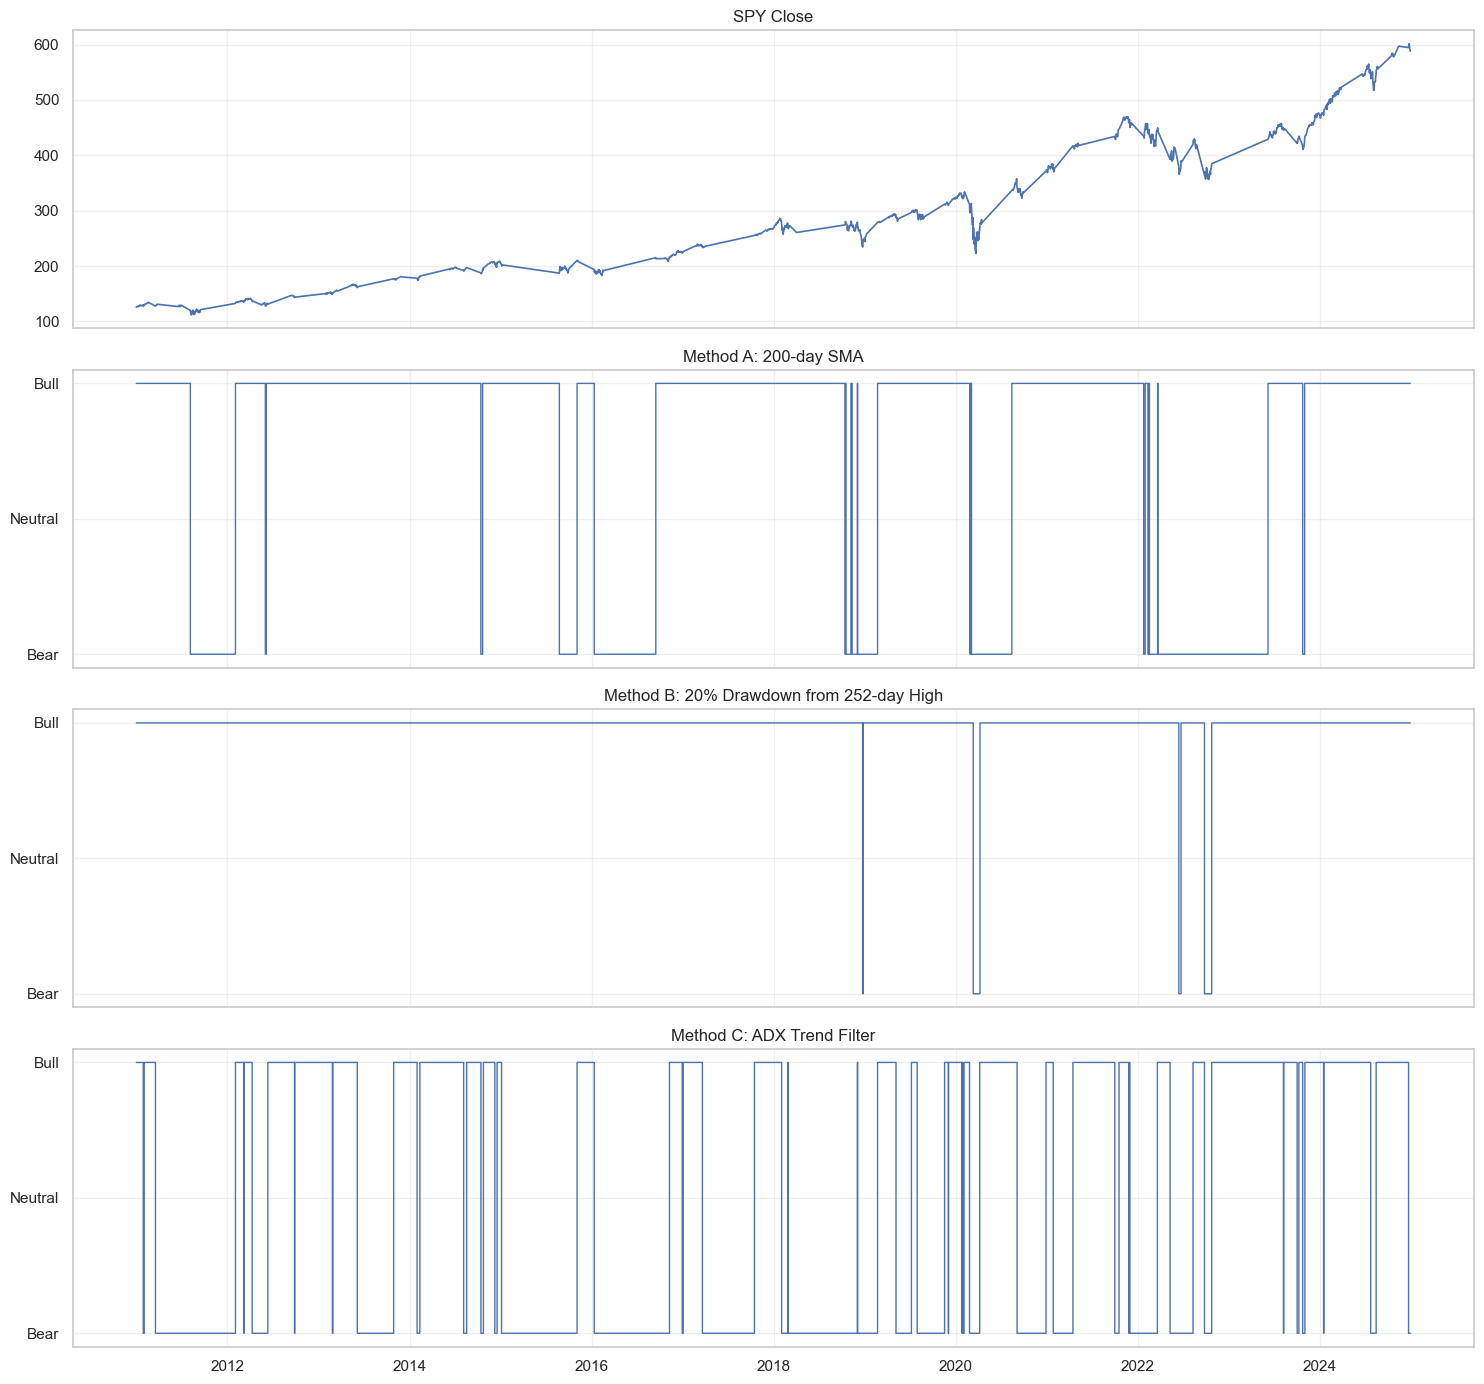

In [5]:
def majority_vote_row(row):
    votes = row.dropna().astype(int).tolist()
    if not votes:
        return np.nan

    counts = pd.Series(votes).value_counts()
    if len(counts) == 1:
        return int(counts.index[0])

    if counts.iloc[0] >= 2:
        return int(counts.index[0])

    return np.nan


labels_df["Final_Label"] = labels_df[["Method_A", "Method_B", "Method_C"]].apply(majority_vote_row, axis=1)
labels_df = labels_df.dropna(subset=["Final_Label"]).copy()
labels_df["Final_Label"] = labels_df["Final_Label"].astype(int)
labels_df["Final_Text"] = labels_df["Final_Label"].map({1: "Bull", 0: "Bear"})

final_bear_periods = contiguous_periods(labels_df["Final_Label"].eq(0))
print_periods("\nFinal label bear-market periods:", final_bear_periods)

print("\nFinal label verification:")
print("2020-Feb to Mar overlap:", overlaps(final_bear_periods, "2020-02-01", "2020-04-30"))
print("2022 year overlap:", overlaps(final_bear_periods, "2022-01-01", "2022-12-31"))

plot_df = labels_df.join(spy_close.rename("SPY_Close"), how="left").dropna().copy()
plot_df["Method_A_Plot"] = plot_df["Method_A"].fillna(0.5)
plot_df["Method_B_Plot"] = plot_df["Method_B"].fillna(0.5)
plot_df["Method_C_Plot"] = plot_df["Method_C"].fillna(0.5)

fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

axes[0].plot(plot_df.index, plot_df["SPY_Close"], linewidth=1.2)
axes[0].set_title("SPY Close")

axes[1].step(plot_df.index, plot_df["Method_A_Plot"], where="post", linewidth=1.0)
axes[1].set_yticks([0, 0.5, 1])
axes[1].set_yticklabels(["Bear", "Neutral", "Bull"])
axes[1].set_title("Method A: 200-day SMA")

axes[2].step(plot_df.index, plot_df["Method_B_Plot"], where="post", linewidth=1.0)
axes[2].set_yticks([0, 0.5, 1])
axes[2].set_yticklabels(["Bear", "Neutral", "Bull"])
axes[2].set_title("Method B: 20% Drawdown from 252-day High")

axes[3].step(plot_df.index, plot_df["Method_C_Plot"], where="post", linewidth=1.0)
axes[3].set_yticks([0, 0.5, 1])
axes[3].set_yticklabels(["Bear", "Neutral", "Bull"])
axes[3].set_title("Method C: ADX Trend Filter")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Feature engineering

In [6]:
price_panel = pd.DataFrame(index=spy.index)
price_panel["SPY_Close"] = spy["Close"]
price_panel["QQQ_Close"] = qqq["Close"]
price_panel["IWM_Close"] = iwm["Close"]
price_panel["GLD_Close"] = gld["Close"]
price_panel["TLT_Close"] = tlt["Close"]
price_panel["VIX_Close"] = vix["Close"]

features_df = pd.DataFrame(index=price_panel.index)

# SPY daily returns used by several features
features_df["SPY_Daily_Return"] = price_panel["SPY_Close"].pct_change()

# Group 1 — SPY technical features
features_df["SPY_Return_5d"] = price_panel["SPY_Close"].pct_change(5)
features_df["SPY_Return_20d"] = price_panel["SPY_Close"].pct_change(20)
features_df["SPY_Return_50d"] = price_panel["SPY_Close"].pct_change(50)

features_df["Realized_Vol_20d"] = features_df["SPY_Daily_Return"].rolling(20).std()

features_df["RSI_14"] = compute_rsi(price_panel["SPY_Close"], window=14)
macd, macd_signal, macd_hist = compute_macd(price_panel["SPY_Close"])
features_df["MACD"] = macd
features_df["MACD_Signal"] = macd_signal
features_df["MACD_Hist"] = macd_hist

features_df["Bollinger_Width_20"] = compute_bollinger_width(price_panel["SPY_Close"], window=20, num_std=2.0)

sma_50 = price_panel["SPY_Close"].rolling(50).mean()

# Group 2 — Cross-asset macro features
features_df["TLT_Return_20d"] = price_panel["TLT_Close"].pct_change(20)
features_df["GLD_Return_20d"] = price_panel["GLD_Close"].pct_change(20)

features_df["VIX_Level"] = price_panel["VIX_Close"]
features_df["VIX_10d_Change"] = price_panel["VIX_Close"].diff(10)

features_df["IWM_SPY_Ratio"] = price_panel["IWM_Close"] / price_panel["SPY_Close"]
features_df["IWM_SPY_Ratio_20d_Mom"] = features_df["IWM_SPY_Ratio"].pct_change(20)

spy_ret_daily = features_df["SPY_Daily_Return"]
tlt_ret_daily = price_panel["TLT_Close"].pct_change()
gld_ret_daily = price_panel["GLD_Close"].pct_change()

features_df["SPY_TLT_Corr_20d"] = spy_ret_daily.rolling(20).corr(tlt_ret_daily)
features_df["SPY_GLD_Corr_20d"] = spy_ret_daily.rolling(20).corr(gld_ret_daily)

# Group 3 — Market breadth proxy
features_df["QQQ_SPY_Ratio"] = price_panel["QQQ_Close"] / price_panel["SPY_Close"]
features_df["QQQ_SPY_Ratio_20d_Trend"] = features_df["QQQ_SPY_Ratio"].pct_change(20)
features_df["QQQ_Return_5d"] = price_panel["QQQ_Close"].pct_change(5)
features_df["QQQ_Return_20d"] = price_panel["QQQ_Close"].pct_change(20)

# Group 4 — Momentum and regime persistence
features_df["Lag_1_Daily_Return"] = features_df["SPY_Daily_Return"].shift(1)
features_df["Rolling_20d_Skewness"] = features_df["SPY_Daily_Return"].rolling(20).skew()

features_df["Autocorr_5d"] = features_df["SPY_Daily_Return"].rolling(5).apply(lambda x: pd.Series(x).autocorr(lag=1), raw=False)
features_df["Autocorr_20d"] = features_df["SPY_Daily_Return"].rolling(20).apply(lambda x: pd.Series(x).autocorr(lag=1), raw=False)

# Attach final labels
features_df["Final_Label"] = labels_df["Final_Label"]

features_df = features_df.replace([np.inf, -np.inf], np.nan).dropna().copy()
features_df["Final_Label"] = features_df["Final_Label"].astype(int)

print(f"Feature dataframe shape: {features_df.shape}")
print(f"Number of features: {features_df.shape[1] - 1}")
print(features_df.head())

Feature dataframe shape: (3328, 27)
Number of features: 26
            SPY_Daily_Return  SPY_Return_5d  SPY_Return_20d  SPY_Return_50d  Realized_Vol_20d    RSI_14     MACD  MACD_Signal  MACD_Hist  Bollinger_Width_20  TLT_Return_20d  \
Date                                                                                                                                                                           
2010-03-17          0.005927       0.018527        0.062035        0.033266          0.005422 77.484480 1.588089     1.141140   0.446948            0.079004        0.023956   
2010-03-18         -0.000512       0.013772        0.055270        0.030010          0.005433 76.874577 1.657873     1.244487   0.413386            0.082350        0.024727   
2010-03-19         -0.009142       0.004417        0.043459        0.019875          0.006046 66.779214 1.608298     1.317249   0.291049            0.082255        0.020235   
2010-03-22          0.005346       0.009525        0.048848  

### Mutual Info


Top 15 features by mutual information:
SPY_Return_50d       0.229982
Realized_Vol_20d     0.200715
MACD                 0.200554
MACD_Signal          0.198854
VIX_Level            0.166705
SPY_Return_20d       0.149129
QQQ_SPY_Ratio        0.145535
Bollinger_Width_20   0.143814
QQQ_Return_20d       0.136089
RSI_14               0.114447
SPY_Return_5d        0.070726
Lag_1_Daily_Return   0.059896
IWM_SPY_Ratio        0.056912
QQQ_Return_5d        0.055092
VIX_10d_Change       0.053467
dtype: float64


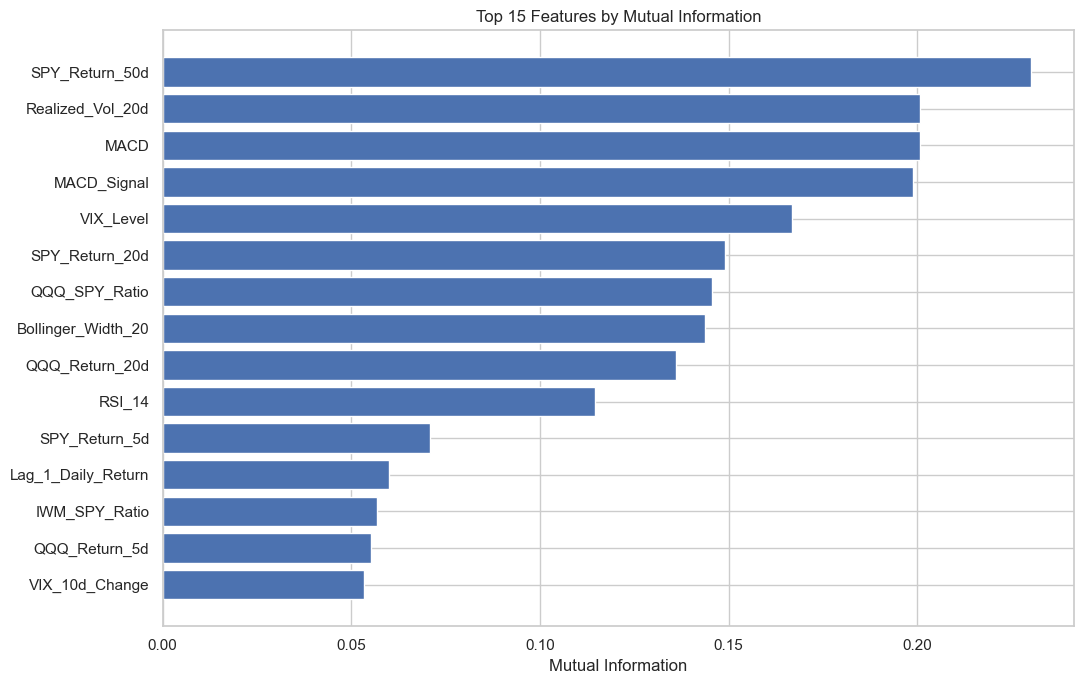

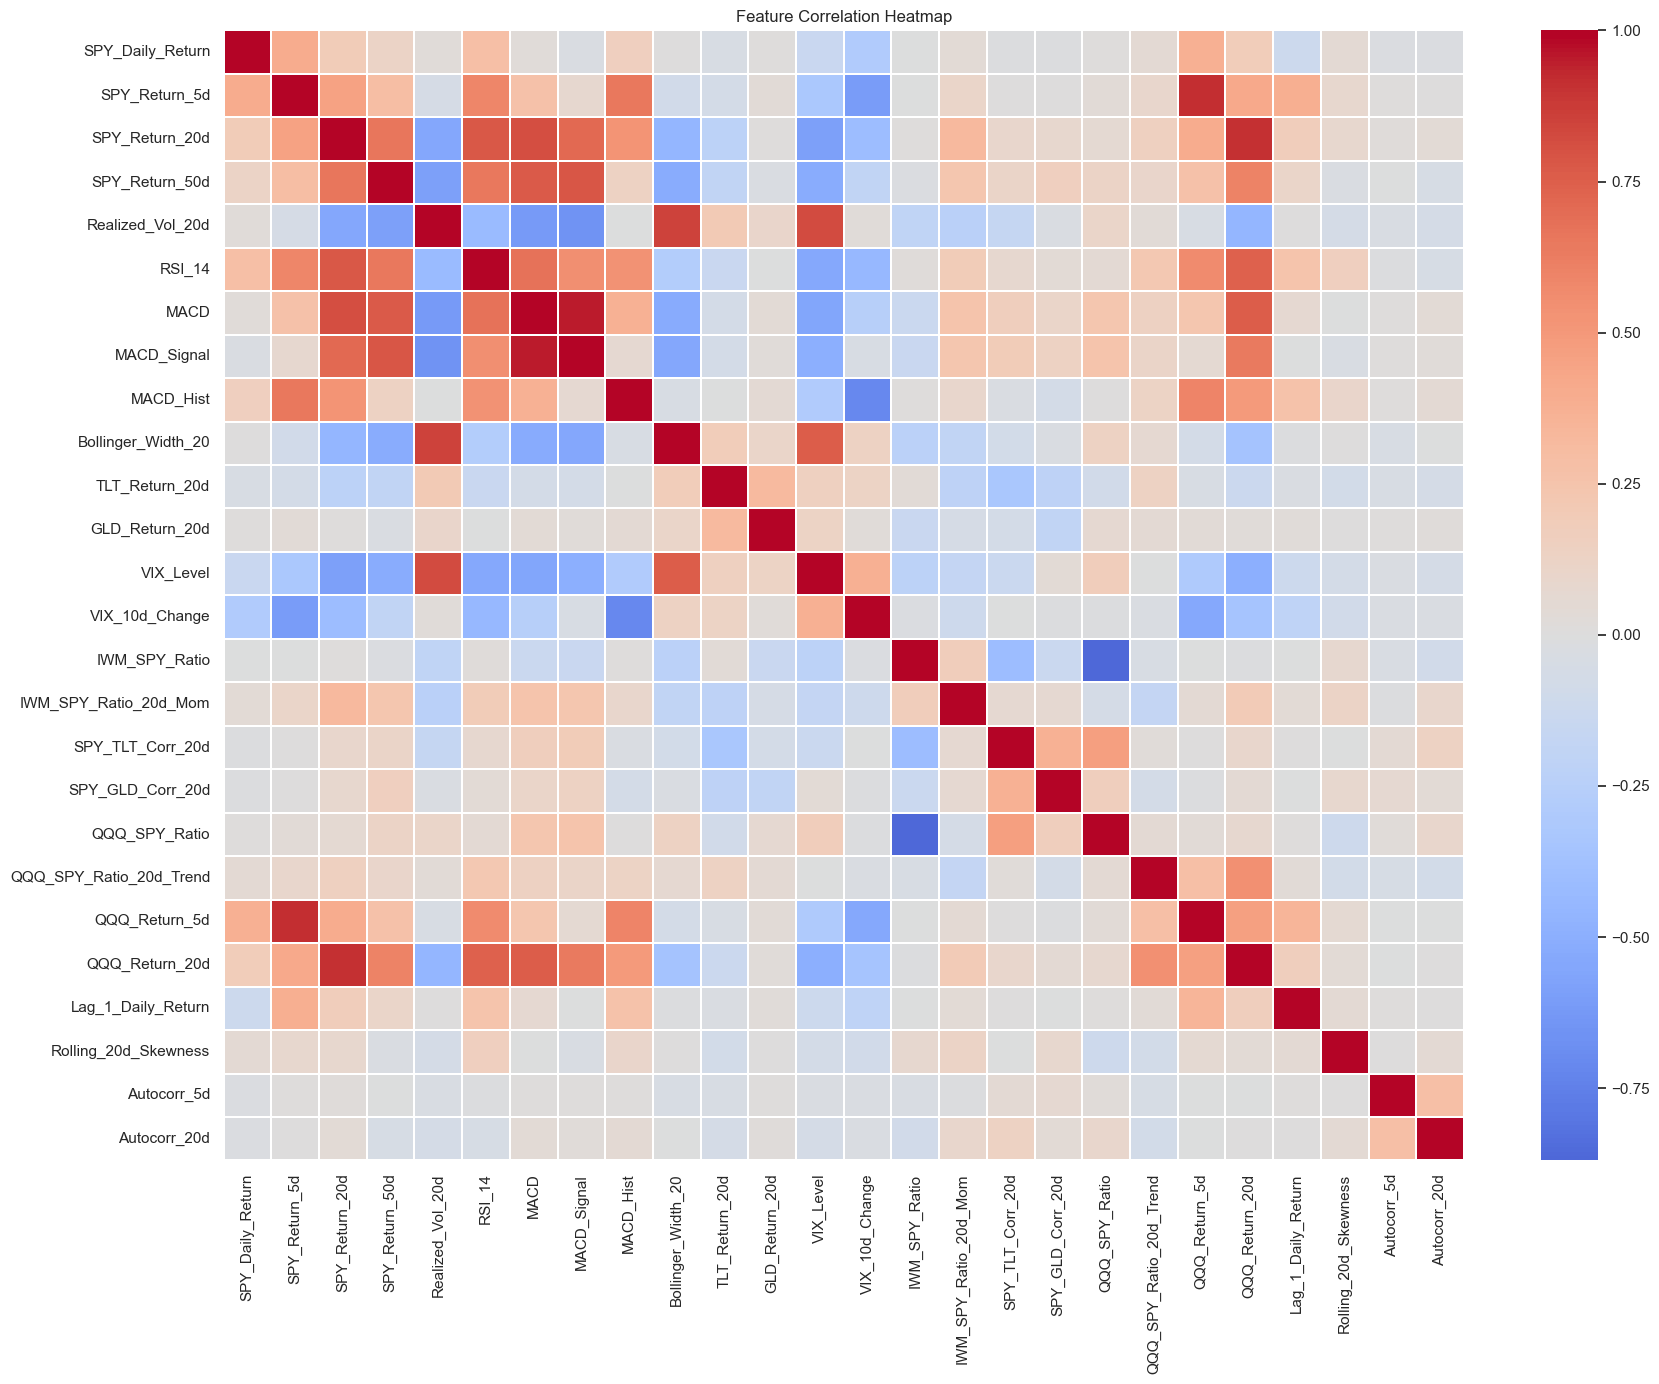

In [7]:
feature_cols = [c for c in features_df.columns if c != "Final_Label"]
X_feat = features_df[feature_cols].copy()
y_feat = features_df["Final_Label"].copy()

mi_scores = mutual_info_classif(X_feat, y_feat, random_state=SEED)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("\nTop 15 features by mutual information:")
print(mi_series.head(15))

top15 = mi_series.head(15).sort_values()

plt.figure(figsize=(11, 7))
plt.barh(top15.index, top15.values)
plt.title("Top 15 Features by Mutual Information")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

corr = X_feat.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Train validation split

In [8]:
df_model = features_df.copy()

train_df = df_model.loc["2010-01-01":"2020-12-31"].copy()
val_df = df_model.loc["2021-01-01":"2022-12-31"].copy()
test_df = df_model.loc["2023-01-01":"2024-12-31"].copy()

model_feature_cols = [c for c in df_model.columns if c != "Final_Label"]

X_train = train_df[model_feature_cols].astype(float)
y_train = train_df["Final_Label"].astype(int)

X_val = val_df[model_feature_cols].astype(float)
y_val = val_df["Final_Label"].astype(int)

X_test = test_df[model_feature_cols].astype(float)
y_test = test_df["Final_Label"].astype(int)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (2445, 26) (2445,)
Val shape: (401, 26) (401,)
Test shape: (482, 26) (482,)


### Model evaluation helpers

In [9]:
def safe_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan


def evaluate_predictions(y_true, y_pred, y_prob=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": safe_auc(y_true, y_prob) if y_prob is not None else np.nan,
    }
    return out


model_outputs = {}
comparison_rows = []

### Logistic regression

In [10]:
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr = scaler_lr.transform(X_val)
X_test_lr = scaler_lr.transform(X_test)

lr_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
lr_model.fit(X_train_lr, y_train)

lr_val_pred = lr_model.predict(X_val_lr)
lr_test_pred = lr_model.predict(X_test_lr)

lr_val_prob = lr_model.predict_proba(X_val_lr)[:, 1]
lr_test_prob = lr_model.predict_proba(X_test_lr)[:, 1]

model_outputs["Logistic Regression"] = {
    "model": lr_model,
    "val_index": X_val.index,
    "val_pred": lr_val_pred,
    "val_prob": lr_val_prob,
    "test_index": X_test.index,
    "test_pred": lr_test_pred,
    "test_prob": lr_test_prob,
    "type": "supervised",
}

print("Logistic Regression — Validation")
print(classification_report(y_val, lr_val_pred, target_names=["Bear", "Bull"], zero_division=0))

print("Logistic Regression — Test")
print(classification_report(y_test, lr_test_pred, target_names=["Bear", "Bull"], zero_division=0))

comparison_rows.append({
    "Model": "Logistic Regression",
    **{f"val_{k}": v for k, v in evaluate_predictions(y_val, lr_val_pred, lr_val_prob).items()},
    **{f"test_{k}": v for k, v in evaluate_predictions(y_test, lr_test_pred, lr_test_prob).items()},
})

Logistic Regression — Validation
              precision    recall  f1-score   support

        Bear       0.86      0.89      0.87        97
        Bull       0.96      0.95      0.96       304

    accuracy                           0.94       401
   macro avg       0.91      0.92      0.92       401
weighted avg       0.94      0.94      0.94       401

Logistic Regression — Test
              precision    recall  f1-score   support

        Bear       0.44      1.00      0.61         7
        Bull       1.00      0.98      0.99       475

    accuracy                           0.98       482
   macro avg       0.72      0.99      0.80       482
weighted avg       0.99      0.98      0.98       482



### Random forest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=SEED,
    class_weight="balanced_subsample",
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

rf_val_prob = rf_model.predict_proba(X_val)[:, 1]
rf_test_prob = rf_model.predict_proba(X_test)[:, 1]

model_outputs["Random Forest"] = {
    "model": rf_model,
    "val_index": X_val.index,
    "val_pred": rf_val_pred,
    "val_prob": rf_val_prob,
    "test_index": X_test.index,
    "test_pred": rf_test_pred,
    "test_prob": rf_test_prob,
    "type": "supervised",
}

print("Random Forest — Validation")
print(classification_report(y_val, rf_val_pred, target_names=["Bear", "Bull"], zero_division=0))

print("Random Forest — Test")
print(classification_report(y_test, rf_test_pred, target_names=["Bear", "Bull"], zero_division=0))

comparison_rows.append({
    "Model": "Random Forest",
    **{f"val_{k}": v for k, v in evaluate_predictions(y_val, rf_val_pred, rf_val_prob).items()},
    **{f"test_{k}": v for k, v in evaluate_predictions(y_test, rf_test_pred, rf_test_prob).items()},
})

Random Forest — Validation
              precision    recall  f1-score   support

        Bear       0.89      0.64      0.74        97
        Bull       0.89      0.97      0.93       304

    accuracy                           0.89       401
   macro avg       0.89      0.81      0.84       401
weighted avg       0.89      0.89      0.89       401

Random Forest — Test
              precision    recall  f1-score   support

        Bear       0.00      0.00      0.00         7
        Bull       0.99      1.00      0.99       475

    accuracy                           0.99       482
   macro avg       0.49      0.50      0.50       482
weighted avg       0.97      0.99      0.98       482



### XGboost

In [12]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    random_state=SEED,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    n_jobs=-1,
    eval_metric="logloss",
)
xgb_model.fit(X_train, y_train)

xgb_val_pred = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]
xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]

model_outputs["XGBoost"] = {
    "model": xgb_model,
    "val_index": X_val.index,
    "val_pred": xgb_val_pred,
    "val_prob": xgb_val_prob,
    "test_index": X_test.index,
    "test_pred": xgb_test_pred,
    "test_prob": xgb_test_prob,
    "type": "supervised",
}

print("XGBoost — Validation")
print(classification_report(y_val, xgb_val_pred, target_names=["Bear", "Bull"], zero_division=0))

print("XGBoost — Test")
print(classification_report(y_test, xgb_test_pred, target_names=["Bear", "Bull"], zero_division=0))

comparison_rows.append({
    "Model": "XGBoost",
    **{f"val_{k}": v for k, v in evaluate_predictions(y_val, xgb_val_pred, xgb_val_prob).items()},
    **{f"test_{k}": v for k, v in evaluate_predictions(y_test, xgb_test_pred, xgb_test_prob).items()},
})

XGBoost — Validation
              precision    recall  f1-score   support

        Bear       0.93      0.79      0.86        97
        Bull       0.94      0.98      0.96       304

    accuracy                           0.94       401
   macro avg       0.93      0.89      0.91       401
weighted avg       0.93      0.94      0.93       401

XGBoost — Test
              precision    recall  f1-score   support

        Bear       0.00      0.00      0.00         7
        Bull       0.99      1.00      0.99       475

    accuracy                           0.99       482
   macro avg       0.49      0.50      0.50       482
weighted avg       0.97      0.99      0.98       482



### HMM

State means on training data: {0: np.float64(0.016681352764808505), 1: np.float64(-0.012312956772036709)}
Bull state: 0, Bear state: 1

HMM — Validation
              precision    recall  f1-score   support

        Bear       0.26      1.00      0.41        97
        Bull       1.00      0.09      0.17       304

    accuracy                           0.31       401
   macro avg       0.63      0.55      0.29       401
weighted avg       0.82      0.31      0.23       401

HMM — Test
              precision    recall  f1-score   support

        Bear       0.01      0.86      0.02         7
        Bull       0.00      0.00      0.00       475

    accuracy                           0.01       482
   macro avg       0.01      0.43      0.01       482
weighted avg       0.00      0.01      0.00       482



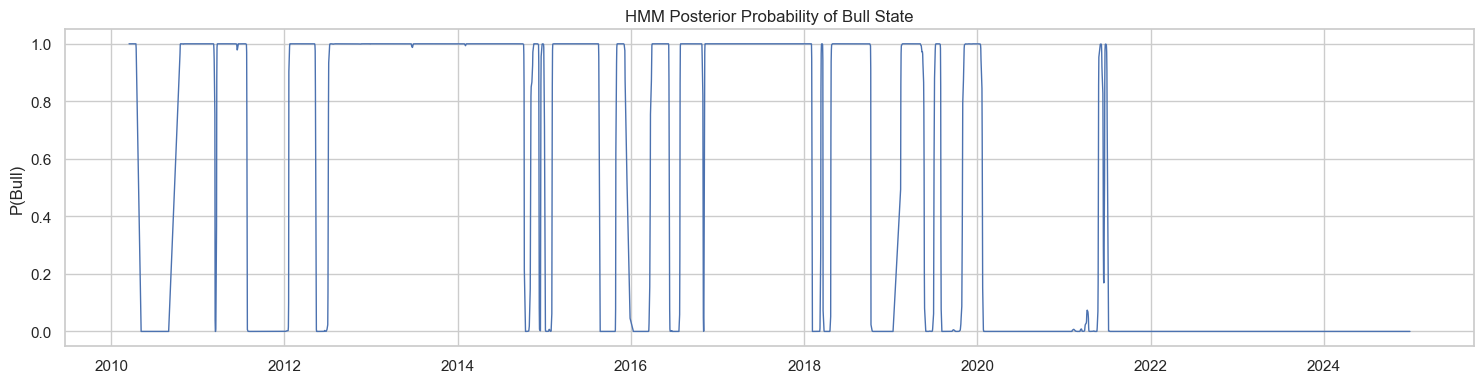

In [13]:
hmm_feature_cols = [
    "SPY_Return_20d",
    "Realized_Vol_20d",
    "TLT_Return_20d",
    "VIX_Level",
    "IWM_SPY_Ratio",
]

hmm_scaler = StandardScaler()
hmm_train_X = hmm_scaler.fit_transform(train_df[hmm_feature_cols].astype(float))
hmm_val_X = hmm_scaler.transform(val_df[hmm_feature_cols].astype(float))
hmm_test_X = hmm_scaler.transform(test_df[hmm_feature_cols].astype(float))
hmm_all_X = hmm_scaler.transform(df_model[hmm_feature_cols].astype(float))

hmm_model = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=200,
    random_state=SEED,
    min_covar=1e-4,
)
hmm_model.fit(hmm_train_X)

hmm_train_states = hmm_model.predict(hmm_train_X)
hmm_val_states = hmm_model.predict(hmm_val_X)
hmm_test_states = hmm_model.predict(hmm_test_X)
hmm_all_states = hmm_model.predict(hmm_all_X)

hmm_train_probs = hmm_model.predict_proba(hmm_train_X)
hmm_val_probs = hmm_model.predict_proba(hmm_val_X)
hmm_test_probs = hmm_model.predict_proba(hmm_test_X)
hmm_all_probs = hmm_model.predict_proba(hmm_all_X)

# Map states by mean SPY 20d return on the training sample
state_means = {}
for s in range(2):
    mask = hmm_train_states == s
    if mask.any():
        state_means[s] = train_df.loc[train_df.index[:len(hmm_train_states)][mask], "SPY_Return_20d"].mean()
    else:
        state_means[s] = -np.inf

bull_state = max(state_means, key=state_means.get)
bear_state = 1 - bull_state

hmm_val_pred = (hmm_val_states == bull_state).astype(int)
hmm_test_pred = (hmm_test_states == bull_state).astype(int)

hmm_val_prob = hmm_val_probs[:, bull_state]
hmm_test_prob = hmm_test_probs[:, bull_state]

model_outputs["HMM"] = {
    "model": hmm_model,
    "val_index": val_df.index,
    "val_pred": hmm_val_pred,
    "val_prob": hmm_val_prob,
    "test_index": test_df.index,
    "test_pred": hmm_test_pred,
    "test_prob": hmm_test_prob,
    "type": "unsupervised",
}

print(f"State means on training data: {state_means}")
print(f"Bull state: {bull_state}, Bear state: {bear_state}")

print("\nHMM — Validation")
print(classification_report(y_val, hmm_val_pred, target_names=["Bear", "Bull"], zero_division=0))

print("HMM — Test")
print(classification_report(y_test, hmm_test_pred, target_names=["Bear", "Bull"], zero_division=0))

comparison_rows.append({
    "Model": "HMM",
    **{f"val_{k}": v for k, v in evaluate_predictions(y_val, hmm_val_pred, hmm_val_prob).items()},
    **{f"test_{k}": v for k, v in evaluate_predictions(y_test, hmm_test_pred, hmm_test_prob).items()},
})

hmm_prob_series = pd.Series(hmm_all_probs[:, bull_state], index=df_model.index)

plt.figure(figsize=(15, 4))
plt.plot(hmm_prob_series.index, hmm_prob_series.values, linewidth=1.0)
plt.title("HMM Posterior Probability of Bull State")
plt.ylabel("P(Bull)")
plt.tight_layout()
plt.show()

#### LSTM

LSTM sequence shapes:
Train: (2426, 20, 26) (2426,)
Val: (401, 20, 26) (401,)
Test: (482, 20, 26) (482,)


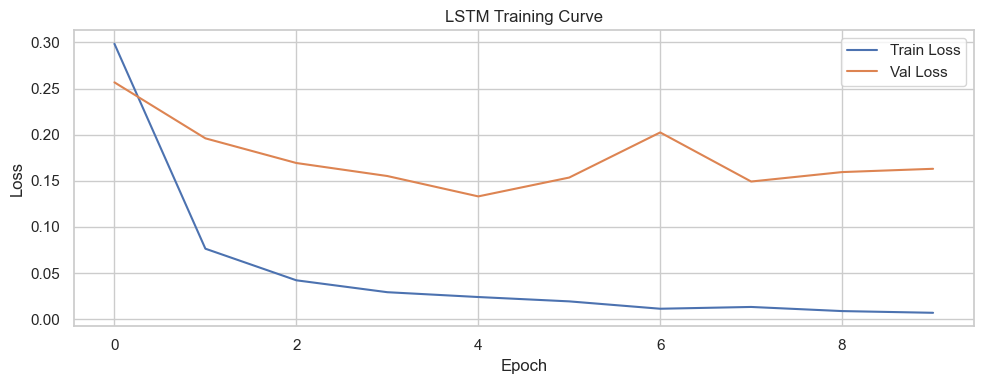

LSTM — Validation
              precision    recall  f1-score   support

        Bear       0.89      0.89      0.89        97
        Bull       0.96      0.96      0.96       304

    accuracy                           0.95       401
   macro avg       0.93      0.93      0.93       401
weighted avg       0.95      0.95      0.95       401

LSTM — Test
              precision    recall  f1-score   support

        Bear       1.00      1.00      1.00         7
        Bull       1.00      1.00      1.00       475

    accuracy                           1.00       482
   macro avg       1.00      1.00      1.00       482
weighted avg       1.00      1.00      1.00       482



In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lookback = 20
lstm_feature_cols = model_feature_cols.copy()

lstm_scaler = StandardScaler()
lstm_scaler.fit(train_df[lstm_feature_cols].astype(float))

X_all_lstm = lstm_scaler.transform(df_model[lstm_feature_cols].astype(float))
y_all_lstm = df_model["Final_Label"].astype(int).values
date_all_lstm = df_model.index

def make_sequences(X, y, dates, lookback_window):
    X_seq, y_seq, d_seq = [], [], []
    for i in range(lookback_window - 1, len(X)):
        X_seq.append(X[i - lookback_window + 1 : i + 1])
        y_seq.append(y[i])
        d_seq.append(dates[i])
    return np.asarray(X_seq), np.asarray(y_seq), pd.DatetimeIndex(d_seq)

X_seq, y_seq, seq_dates = make_sequences(X_all_lstm, y_all_lstm, date_all_lstm, lookback)

train_mask_seq = (seq_dates >= pd.Timestamp("2010-01-01")) & (seq_dates <= pd.Timestamp("2020-12-31"))
val_mask_seq = (seq_dates >= pd.Timestamp("2021-01-01")) & (seq_dates <= pd.Timestamp("2022-12-31"))
test_mask_seq = (seq_dates >= pd.Timestamp("2023-01-01")) & (seq_dates <= pd.Timestamp("2024-12-31"))

X_train_seq, y_train_seq = X_seq[train_mask_seq], y_seq[train_mask_seq]
X_val_seq, y_val_seq = X_seq[val_mask_seq], y_seq[val_mask_seq]
X_test_seq, y_test_seq = X_seq[test_mask_seq], y_seq[test_mask_seq]

val_seq_dates = seq_dates[val_mask_seq]
test_seq_dates = seq_dates[test_mask_seq]

print("LSTM sequence shapes:")
print("Train:", X_train_seq.shape, y_train_seq.shape)
print("Val:", X_val_seq.shape, y_val_seq.shape)
print("Test:", X_test_seq.shape, y_test_seq.shape)

# Convert to torch tensors
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val_seq, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val_seq, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# Model
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, 64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(64, 32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        x = x[:, -1, :]
        x = torch.sigmoid(self.fc(x))
        return x.squeeze()

lstm_model = LSTMModel(len(lstm_feature_cols)).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

# Training loop with early stopping
train_losses, val_losses = [], []
best_val_loss = float("inf")
patience, patience_counter = 5, 0
best_state = None

for epoch in range(30):
    lstm_model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = lstm_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)

    epoch_loss /= len(X_train_t)

    lstm_model.eval()
    with torch.no_grad():
        val_preds = lstm_model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = lstm_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        break

# restore best weights
lstm_model.load_state_dict(best_state)

# Plot losses
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Predictions
lstm_model.eval()
with torch.no_grad():
    lstm_val_prob = lstm_model(X_val_t).cpu().numpy().ravel()
    lstm_test_prob = lstm_model(X_test_t).cpu().numpy().ravel()

lstm_val_pred = (lstm_val_prob >= 0.5).astype(int)
lstm_test_pred = (lstm_test_prob >= 0.5).astype(int)

model_outputs["LSTM"] = {
    "model": lstm_model,
    "val_index": val_seq_dates,
    "val_pred": lstm_val_pred,
    "val_prob": lstm_val_prob,
    "test_index": test_seq_dates,
    "test_pred": lstm_test_pred,
    "test_prob": lstm_test_prob,
    "type": "supervised",
}

print("LSTM — Validation")
print(classification_report(y_val_seq, lstm_val_pred, target_names=["Bear", "Bull"], zero_division=0))

print("LSTM — Test")
print(classification_report(y_test_seq, lstm_test_pred, target_names=["Bear", "Bull"], zero_division=0))

comparison_rows.append({
    "Model": "LSTM",
    **{f"val_{k}": v for k, v in evaluate_predictions(y_val_seq, lstm_val_pred, lstm_val_prob).items()},
    **{f"test_{k}": v for k, v in evaluate_predictions(y_test_seq, lstm_test_pred, lstm_test_prob).items()},
})

### Comparison Table

In [15]:
comparison_df = pd.DataFrame(comparison_rows).set_index("Model").sort_values("val_f1", ascending=False)

print("\nFull model comparison table:")
display(comparison_df)

supervised_models = ["Logistic Regression", "Random Forest", "XGBoost", "LSTM"]
supervised_val_scores = comparison_df.loc[supervised_models, "val_f1"].sort_values(ascending=False)
top3_models = supervised_val_scores.head(3).index.tolist()

print("\nTop 3 supervised models by validation F1:")
print(top3_models)

def aligned_majority_vote(store, model_names, split="test"):
    pred_series = []
    for name in model_names:
        idx = pd.Index(store[name][f"{split}_index"])
        pred = pd.Series(store[name][f"{split}_pred"], index=idx, name=name)
        pred_series.append(pred)

    aligned = pd.concat(pred_series, axis=1, join="inner").dropna()
    voted = (aligned.sum(axis=1) >= (len(model_names) / 2)).astype(int)
    return aligned.index, voted

ensemble_val_index, ensemble_val_pred = aligned_majority_vote(model_outputs, top3_models, split="val")
ensemble_test_index, ensemble_test_pred = aligned_majority_vote(model_outputs, top3_models, split="test")

ensemble_val_y = df_model.loc[ensemble_val_index, "Final_Label"].astype(int)
ensemble_test_y = df_model.loc[ensemble_test_index, "Final_Label"].astype(int)

print("\nEnsemble — Validation")
print(classification_report(ensemble_val_y, ensemble_val_pred, target_names=["Bear", "Bull"], zero_division=0))

print("Ensemble — Test")
print(classification_report(ensemble_test_y, ensemble_test_pred, target_names=["Bear", "Bull"], zero_division=0))

comparison_df.loc["Ensemble"] = {
    "val_accuracy": accuracy_score(ensemble_val_y, ensemble_val_pred),
    "val_precision": precision_score(ensemble_val_y, ensemble_val_pred, zero_division=0),
    "val_recall": recall_score(ensemble_val_y, ensemble_val_pred, zero_division=0),
    "val_f1": f1_score(ensemble_val_y, ensemble_val_pred, zero_division=0),
    "val_auc": np.nan,
    "test_accuracy": accuracy_score(ensemble_test_y, ensemble_test_pred),
    "test_precision": precision_score(ensemble_test_y, ensemble_test_pred, zero_division=0),
    "test_recall": recall_score(ensemble_test_y, ensemble_test_pred, zero_division=0),
    "test_f1": f1_score(ensemble_test_y, ensemble_test_pred, zero_division=0),
    "test_auc": np.nan,
}

comparison_df = comparison_df.sort_values("val_f1", ascending=False)

print("\nComparison table including ensemble:")
display(comparison_df)


Full model comparison table:


,val_accuracy,val_precision,val_recall,val_f1,val_auc,test_accuracy,test_precision,test_recall,test_f1,test_auc
Model,,,,,,,,,,
LSTM,0.945137,0.963816,0.963816,0.963816,0.982552,1.000000,1.000000,1.000000,1.000000,1.000000
Logistic Regression,0.937656,0.963455,0.953947,0.958678,0.987859,0.981328,1.000000,0.981053,0.990436,0.994887
XGBoost,0.935162,0.937107,0.980263,0.958199,0.985587,0.985477,0.985477,1.000000,0.992685,0.990376
Random Forest,0.892768,0.894260,0.973684,0.932283,0.977618,0.985477,0.985477,1.000000,0.992685,0.982556
HMM,0.311721,1.000000,0.092105,0.168675,0.982366,0.012448,0.000000,0.000000,0.000000,0.707368



Top 3 supervised models by validation F1:
['LSTM', 'Logistic Regression', 'XGBoost']

Ensemble — Validation
              precision    recall  f1-score   support

        Bear       0.87      0.82      0.85        97
        Bull       0.94      0.96      0.95       304

    accuracy                           0.93       401
   macro avg       0.91      0.89      0.90       401
weighted avg       0.93      0.93      0.93       401

Ensemble — Test
              precision    recall  f1-score   support

        Bear       1.00      1.00      1.00         7
        Bull       1.00      1.00      1.00       475

    accuracy                           1.00       482
   macro avg       1.00      1.00      1.00       482
weighted avg       1.00      1.00      1.00       482


Comparison table including ensemble:


,val_accuracy,val_precision,val_recall,val_f1,val_auc,test_accuracy,test_precision,test_recall,test_f1,test_auc
Model,,,,,,,,,,
LSTM,0.945137,0.963816,0.963816,0.963816,0.982552,1.000000,1.000000,1.000000,1.000000,1.000000
Logistic Regression,0.937656,0.963455,0.953947,0.958678,0.987859,0.981328,1.000000,0.981053,0.990436,0.994887
XGBoost,0.935162,0.937107,0.980263,0.958199,0.985587,0.985477,0.985477,1.000000,0.992685,0.990376
Ensemble,0.927681,0.944984,0.960526,0.952692,NaN,1.000000,1.000000,1.000000,1.000000,NaN
Random Forest,0.892768,0.894260,0.973684,0.932283,0.977618,0.985477,0.985477,1.000000,0.992685,0.982556
HMM,0.311721,1.000000,0.092105,0.168675,0.982366,0.012448,0.000000,0.000000,0.000000,0.707368


### Walk forward validation

Walk-forward fold results:


,fold_start,fold_end,f1
0,2013-01-01,2013-06-30,1.000000
1,2013-07-01,2013-12-31,1.000000
2,2014-01-01,2014-06-30,1.000000
3,2014-07-01,2014-12-31,0.979757
4,2015-01-01,2015-06-30,1.000000
5,2015-07-01,2015-12-31,0.898551
6,2016-01-01,2016-06-30,0.987179
7,2016-07-01,2016-12-31,1.000000
8,2017-01-01,2017-06-30,1.000000
9,2017-07-01,2017-12-31,1.000000


Mean F1: 0.9478
Std F1: 0.0978


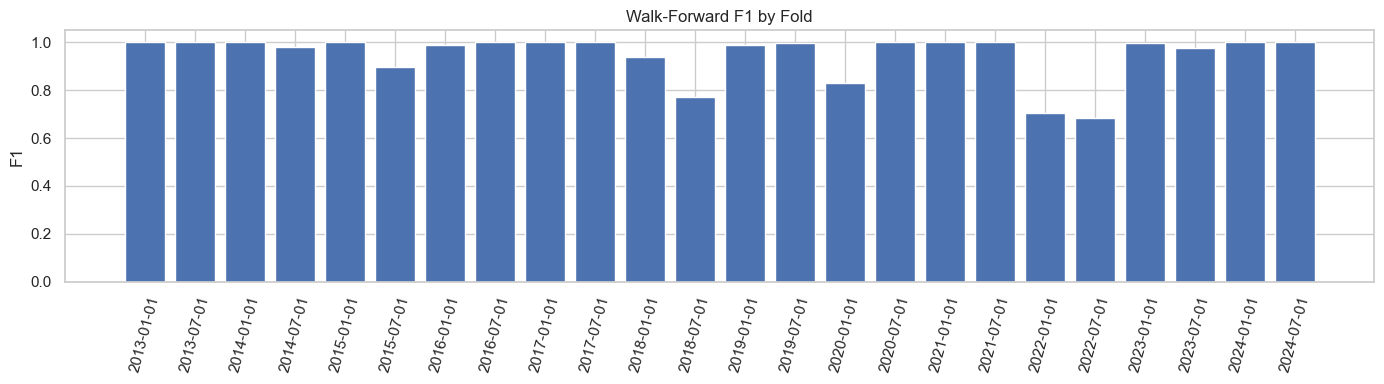

In [16]:
wf_df = df_model.copy()
wf_start = pd.Timestamp("2010-01-01")
wf_end = pd.Timestamp("2024-12-31")

train_window_years = 3
test_window_months = 6
step_months = 6

fold_rows = []
fold_start = wf_start

while True:
    train_start = fold_start
    train_end = train_start + pd.DateOffset(years=train_window_years) - pd.Timedelta(days=1)
    test_start = train_end + pd.Timedelta(days=1)
    test_end = test_start + pd.DateOffset(months=test_window_months) - pd.Timedelta(days=1)

    if test_start > wf_end:
        break

    train_fold = wf_df.loc[train_start:train_end]
    test_fold = wf_df.loc[test_start:test_end]

    if len(train_fold) < 100 or len(test_fold) < 20:
        fold_start = fold_start + pd.DateOffset(months=step_months)
        continue

    X_train_fold = train_fold[model_feature_cols].astype(float)
    y_train_fold = train_fold["Final_Label"].astype(int)
    X_test_fold = test_fold[model_feature_cols].astype(float)
    y_test_fold = test_fold["Final_Label"].astype(int)

    scaler_fold = StandardScaler()
    X_train_fold_s = scaler_fold.fit_transform(X_train_fold)
    X_test_fold_s = scaler_fold.transform(X_test_fold)

    rf_fold = RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=SEED,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )
    rf_fold.fit(X_train_fold, y_train_fold)
    fold_pred = rf_fold.predict(X_test_fold)

    fold_f1 = f1_score(y_test_fold, fold_pred, zero_division=0)

    fold_rows.append({
        "fold_start": test_start,
        "fold_end": test_end,
        "f1": fold_f1,
    })

    fold_start = fold_start + pd.DateOffset(months=step_months)

wf_results = pd.DataFrame(fold_rows)

print("Walk-forward fold results:")
display(wf_results)

print(f"Mean F1: {wf_results['f1'].mean():.4f}")
print(f"Std F1: {wf_results['f1'].std(ddof=1):.4f}")

plt.figure(figsize=(14, 4))
plt.bar(wf_results["fold_start"].astype(str), wf_results["f1"])
plt.xticks(rotation=75)
plt.title("Walk-Forward F1 by Fold")
plt.ylabel("F1")
plt.tight_layout()
plt.show()

### Backtest utilities

In [17]:
def performance_stats(strategy_returns: pd.Series):
    strategy_returns = strategy_returns.dropna()
    if strategy_returns.empty:
        return {
            "total_return": np.nan,
            "annualized_return": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
        }

    equity = (1 + strategy_returns).cumprod()
    total_return = equity.iloc[-1] - 1
    annualized_return = equity.iloc[-1] ** (252 / len(strategy_returns)) - 1

    vol = strategy_returns.std(ddof=0)
    sharpe = np.nan if vol == 0 else np.sqrt(252) * strategy_returns.mean() / vol

    drawdown = equity / equity.cummax() - 1
    max_drawdown = drawdown.min()

    return {
        "total_return": float(total_return),
        "annualized_return": float(annualized_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown),
    }


def backtest_from_signal(signal: pd.Series, asset_returns: pd.Series, long_bull_bear_bear=False):
    signal = signal.astype(float).sort_index()
    asset_returns = asset_returns.reindex(signal.index).astype(float)

    # Use prior-day signal to avoid look-ahead
    shifted_signal = signal.shift(1).fillna(0.0)

    if long_bull_bear_bear:
        position = np.where(shifted_signal >= 0.5, 1.0, -1.0)
    else:
        position = np.where(shifted_signal >= 0.5, 1.0, 0.0)

    strategy_returns = pd.Series(position, index=signal.index) * asset_returns
    equity = (1 + strategy_returns.fillna(0.0)).cumprod()

    switches = int((signal != signal.shift(1)).sum() - 1) if len(signal) > 1 else 0
    transitions = signal.index[signal.ne(signal.shift(1))].tolist()
    transitions = transitions[1:] if len(transitions) > 0 else []

    return strategy_returns, equity, switches, transitions


def choose_best_model_by_val(comparison, models_to_consider):
    subset = comparison.loc[models_to_consider].sort_values("val_f1", ascending=False)
    return subset.index[0]

### Backtest on 2023-2024

In [18]:
best_model_name = choose_best_model_by_val(comparison_df, ["Logistic Regression", "Random Forest", "XGBoost", "HMM", "LSTM"])
print("Best model by validation F1:", best_model_name)

best_store = model_outputs[best_model_name]
best_test_idx = pd.Index(best_store["test_index"])
best_test_pred = pd.Series(best_store["test_pred"], index=best_test_idx, name="signal").sort_index()

test_market = price_panel.loc[best_test_idx].copy()
test_market["SPY_Return"] = test_market["SPY_Close"].pct_change().reindex(best_test_idx)

# Strategy A: long in Bull, cash in Bear
signal_a = best_test_pred.copy()
ret_a, eq_a, switches_a, transitions_a = backtest_from_signal(signal_a, test_market["SPY_Return"], long_bull_bear_bear=False)

# Strategy B: long in Bull, short in Bear
ret_b, eq_b, switches_b, transitions_b = backtest_from_signal(signal_a, test_market["SPY_Return"], long_bull_bear_bear=True)

# Benchmark: buy and hold
bench_ret = test_market["SPY_Return"].fillna(0.0)
bench_eq = (1 + bench_ret).cumprod()

stats_a = performance_stats(ret_a)
stats_b = performance_stats(ret_b)
stats_bench = performance_stats(bench_ret)

stats_table = pd.DataFrame({
    "Strategy A": stats_a,
    "Strategy B": stats_b,
    "Benchmark": stats_bench,
}).T

stats_table["regime_switches"] = [switches_a, switches_b, np.nan]

print("\nBacktest performance summary:")
display(stats_table)

print("\nRegime transitions detected:")
for dt in transitions_a:
    print(dt.date())

print(f"\nStrategy A regime switches: {switches_a}")
print(f"Strategy B regime switches: {switches_b}")

Best model by validation F1: LSTM

Backtest performance summary:


,total_return,annualized_return,sharpe,max_drawdown,regime_switches
Strategy A,0.430818,0.206458,1.588982,-0.087901,3.000000
Strategy B,0.321456,0.157232,1.194237,-0.116603,3.000000
Benchmark,0.544614,0.255218,1.831024,-0.102907,NaN



Regime transitions detected:
2023-01-13
2023-10-25
2023-11-02

Strategy A regime switches: 3
Strategy B regime switches: 3


### Backtest plots

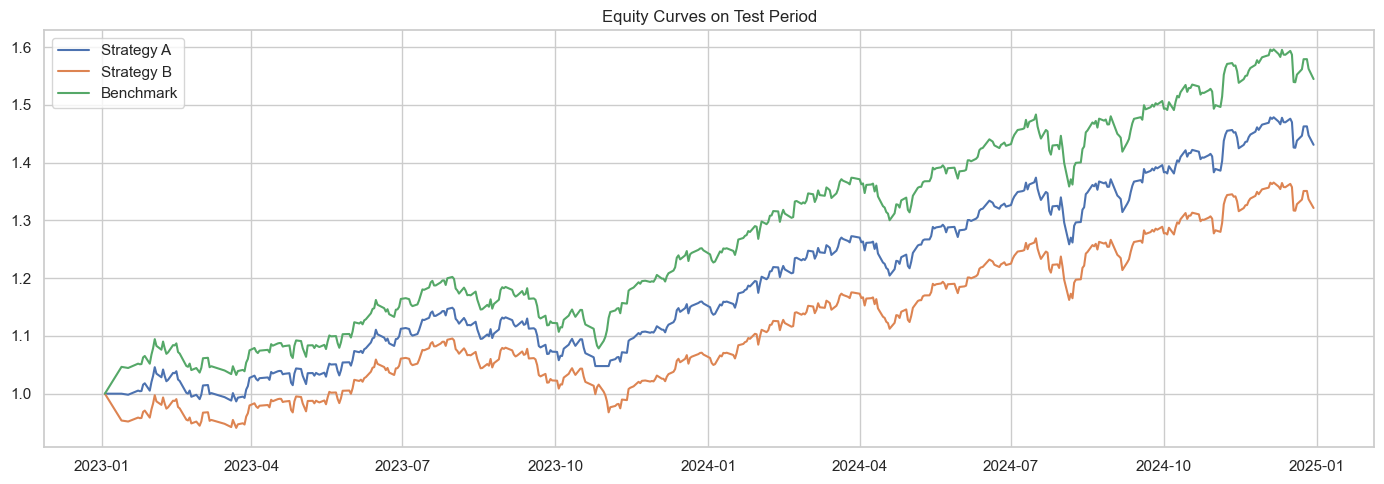

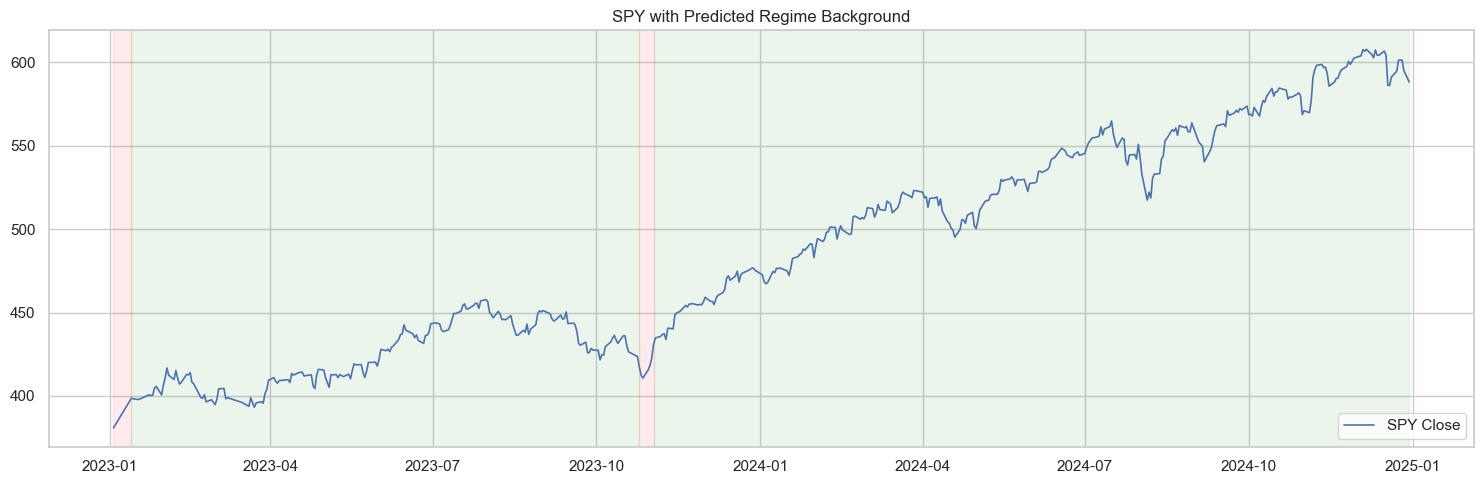

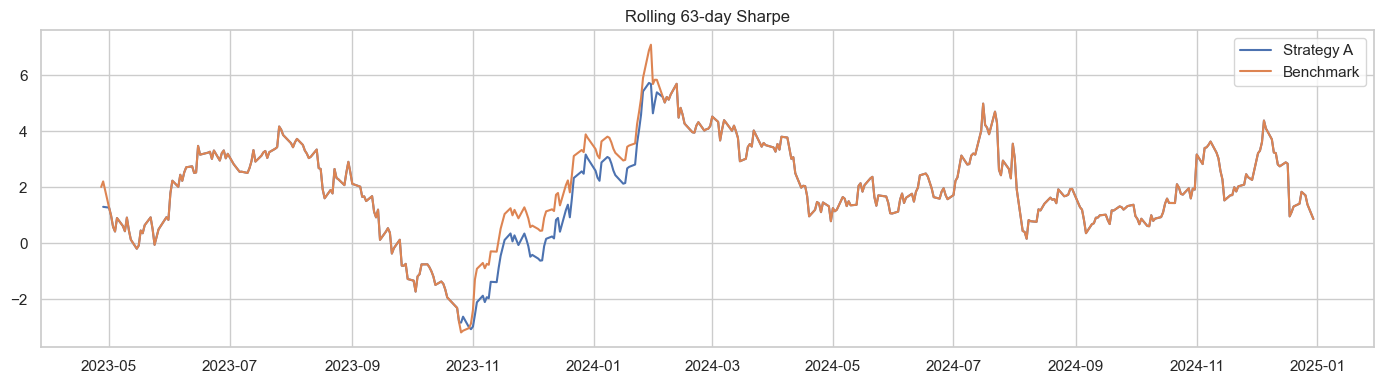

In [19]:
# Equity curves
plt.figure(figsize=(14, 5))
plt.plot(eq_a.index, eq_a.values, label="Strategy A")
plt.plot(eq_b.index, eq_b.values, label="Strategy B")
plt.plot(bench_eq.index, bench_eq.values, label="Benchmark")
plt.title("Equity Curves on Test Period")
plt.legend()
plt.tight_layout()
plt.show()

# Regime timeline on SPY chart
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(test_market.index, test_market["SPY_Close"], linewidth=1.2, label="SPY Close")

sig = signal_a.reindex(test_market.index).dropna().astype(int)
if len(sig) > 0:
    start = sig.index[0]
    current = sig.iloc[0]
    prev = sig.index[0]

    for dt, val in sig.iloc[1:].items():
        if val != current:
            color = "green" if current == 1 else "red"
            ax.axvspan(prev, dt, color=color, alpha=0.08)
            prev = dt
            current = val

    color = "green" if current == 1 else "red"
    ax.axvspan(prev, sig.index[-1], color=color, alpha=0.08)

ax.set_title("SPY with Predicted Regime Background")
ax.legend()
plt.tight_layout()
plt.show()

# Rolling 63-day Sharpe
roll_window = 63
roll_sharpe_a = (
    ret_a.rolling(roll_window).mean() / ret_a.rolling(roll_window).std(ddof=0)
) * np.sqrt(252)

roll_sharpe_bench = (
    bench_ret.rolling(roll_window).mean() / bench_ret.rolling(roll_window).std(ddof=0)
) * np.sqrt(252)

plt.figure(figsize=(14, 4))
plt.plot(roll_sharpe_a.index, roll_sharpe_a.values, label="Strategy A")
plt.plot(roll_sharpe_bench.index, roll_sharpe_bench.values, label="Benchmark")
plt.title("Rolling 63-day Sharpe")
plt.legend()
plt.tight_layout()
plt.show()

### MLflow logging

In [20]:
try:
    import mlflow
    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment("Bull_Bear_Regime_Experiment")

    with mlflow.start_run(run_name="bull_bear_summary"):
        mlflow.log_param("lookback", 20)
        mlflow.log_param("train_window_years", 3)
        mlflow.log_param("prediction_window_months", 6)
        mlflow.log_param("step_months", 6)
        mlflow.log_param("best_model", best_model_name)
        mlflow.log_param("ensemble_models", ",".join(top3_models))

        for model_name, row in comparison_df.iterrows():
            for metric_name in ["val_accuracy", "val_precision", "val_recall", "val_f1", "val_auc",
                                "test_accuracy", "test_precision", "test_recall", "test_f1", "test_auc"]:
                value = row.get(metric_name, np.nan)
                if pd.notna(value):
                    mlflow.log_metric(f"{model_name}_{metric_name}", float(value))

        mlflow.log_metric("walk_forward_f1_mean", float(wf_results["f1"].mean()))
        mlflow.log_metric("walk_forward_f1_std", float(wf_results["f1"].std(ddof=1)))
        mlflow.log_metric("strategy_a_total_return", stats_a["total_return"])
        mlflow.log_metric("strategy_a_sharpe", stats_a["sharpe"])
        mlflow.log_metric("strategy_a_max_drawdown", stats_a["max_drawdown"])
        mlflow.log_metric("strategy_b_total_return", stats_b["total_return"])
        mlflow.log_metric("strategy_b_sharpe", stats_b["sharpe"])
        mlflow.log_metric("strategy_b_max_drawdown", stats_b["max_drawdown"])

    print("MLflow run logged successfully.")
except Exception as e:
    print(f"MLflow skipped: {e}")

2026/04/28 00:59:33 INFO mlflow.tracking.fluent: Experiment with name 'Bull_Bear_Regime_Experiment' does not exist. Creating a new experiment.


MLflow run logged successfully.


### Summary 

In [21]:
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"Best model by validation F1: {best_model_name}")
print(f"Top 3 supervised models: {top3_models}")
print(f"Walk-forward F1 mean: {wf_results['f1'].mean():.4f}")
print(f"Walk-forward F1 std: {wf_results['f1'].std(ddof=1):.4f}")
print(f"Strategy A total return: {stats_a['total_return']:.4f}")
print(f"Strategy A Sharpe: {stats_a['sharpe']:.4f}")
print(f"Strategy A max drawdown: {stats_a['max_drawdown']:.4f}")
print(f"Strategy B total return: {stats_b['total_return']:.4f}")
print(f"Strategy B Sharpe: {stats_b['sharpe']:.4f}")
print(f"Strategy B max drawdown: {stats_b['max_drawdown']:.4f}")
print("=" * 80)


FINAL SUMMARY
Best model by validation F1: LSTM
Top 3 supervised models: ['LSTM', 'Logistic Regression', 'XGBoost']
Walk-forward F1 mean: 0.9478
Walk-forward F1 std: 0.0978
Strategy A total return: 0.4308
Strategy A Sharpe: 1.5890
Strategy A max drawdown: -0.0879
Strategy B total return: 0.3215
Strategy B Sharpe: 1.1942
Strategy B max drawdown: -0.1166
